In [1]:
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import numpy as np
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.layers import Dense, Dropout
from lime.lime_tabular import LimeTabularExplainer
import shap
from collections import defaultdict
import re
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

In [2]:

wine_qt_path = '../data/WineQT.csv'
RANDOM_SEED = 492
wine_df = pd.read_csv(wine_qt_path)
y_series = wine_df['quality']
y = pd.DataFrame(y_series, columns=['quality'])
features = [col for col in wine_df.columns if col != 'Id' and col != 'quality']
X = wine_df[features]
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_series)
y_encoded = pd.DataFrame(y_encoded, columns=['quality'])
y_onehot = tf.keras.utils.to_categorical(y_encoded)
print(y_onehot)

[[0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 ...
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]


In [3]:
# Get the minimum and maximum values from y_series
min_quality = y_series.min()
max_quality = y_series.max()

print("Minimum quality:", min_quality)
print("Maximum quality:", max_quality)
unique_values = y_series.unique()
print("Unique values in y_series:", len(unique_values))

Minimum quality: 3
Maximum quality: 8
Unique values in y_series: 6


In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=RANDOM_SEED)
X_train = X_train.reset_index(drop=True)
# y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
# y_test = y_test.reset_index(drop=True)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
# Convert y_train and y_test to DataFrames with appropriate column names
y_train = pd.DataFrame(y_train, columns=[f'class_{i}' for i in range(y_onehot.shape[1])])
y_test = pd.DataFrame(y_test, columns=[f'class_{i}' for i in range(y_onehot.shape[1])])

np.random.seed(RANDOM_SEED)
y_train_shuffled = y_train.copy()
y_train_shuffled = np.random.permutation(y_train_shuffled.values)
y_train_shuffled = pd.DataFrame(y_train_shuffled)

In [98]:
# Print shapes to verify
print("Shape of X_train_scaled:", y_train.head())
print("Shape of y_train:", y_train_shuffled.head())

Shape of X_train_scaled:    class_0  class_1  class_2  class_3  class_4  class_5
0      0.0      0.0      0.0      0.0      1.0      0.0
1      0.0      0.0      1.0      0.0      0.0      0.0
2      0.0      0.0      0.0      0.0      1.0      0.0
3      0.0      0.0      0.0      1.0      0.0      0.0
4      0.0      0.0      0.0      1.0      0.0      0.0
Shape of y_train:      0    1    2    3    4    5
0  0.0  0.0  0.0  1.0  0.0  0.0
1  0.0  0.0  0.0  1.0  0.0  0.0
2  0.0  0.0  1.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0  1.0  0.0
4  0.0  0.0  1.0  0.0  0.0  0.0


In [137]:
import tensorflow as tf
from tensorflow.keras.layers import LayerNormalization, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MultiHeadAttention
from lime.lime_tabular import LimeTabularExplainer
import shap
import numpy as np
import pandas as pd


class FeatureTokenizer(tf.keras.layers.Layer):
    def __init__(self, num_features, embed_dim):
        super(FeatureTokenizer, self).__init__()
        self.num_features = num_features
        self.embed_dim = embed_dim
        
        self.feature_weights = self.add_weight(shape=(num_features, embed_dim),
                                               initializer='random_normal',
                                               trainable=True)
        self.feature_bias = self.add_weight(shape=(num_features, embed_dim),
                                            initializer='random_normal',
                                            trainable=True)
        self.layer_norm = LayerNormalization()
    
    def call(self, inputs):
        # Remove unnecessary extra dimension
        print("Inputs shape before expansion in tokenizer call:", inputs.shape)
        
        embeddings = inputs[:, :, tf.newaxis] * self.feature_weights + self.feature_bias
        print("Embeddings shape after expansion and weight application in tokenizer call:", embeddings.shape)
        embeddings = self.layer_norm(embeddings)
        print("Embeddings shape after layer normalization in tokenizer call:", embeddings.shape)
        return embeddings


class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, attention_mask=None, training=False):
        attn_output = self.att(inputs, inputs) #, inputs, attention_mask=attention_mask
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


class FTTransformer(tf.keras.Model):
    def __init__(self, embed_dim, dim_out, depth, heads, ff_dim, mlp_hidden, attn_dropout=0.1, ff_dropout=0.1):
        super(FTTransformer, self).__init__()
        self.transformers = [TransformerBlock(embed_dim, heads, ff_dim, rate=attn_dropout) for _ in range(depth)]
        # self.flatten_transformer_output = Flatten()
        self.global_pooling = tf.keras.layers.GlobalAveragePooling1D()
        self.mlp_layers = [Dense(size, activation=activation) for size, activation in mlp_hidden]
        self.output_layer = Dense(dim_out)
    
    def call(self, inputs, attention_mask=None, training=False):
        print("Input shape to Transformer:", inputs.shape)
        x = inputs
        for transformer in self.transformers:
            x = transformer(x, attention_mask=attention_mask, training=training)
            print("Shape after Transformer block:", x.shape)
        x = self.global_pooling(x)
        print("Shape after Global pooling:", x.shape)
        for mlp_layer in self.mlp_layers:
            x = mlp_layer(x)
            print("Shape after MLP layer:", x.shape)
        x = self.output_layer(x)
        print("Shape after output layer:", x.shape)
        return x

In [157]:
class SimpleMLPModel(tf.keras.Model):
    def __init__(self, num_features, embed_dim, dim_out=1, depth=2, heads=4, ff_dim=128, mlp_hidden=[(128, 'relu'), (64, 'relu')], hidden_dim=64, dropout_rate=0.1, num_classes=6):
        super(SimpleMLPModel, self).__init__()
        self.feature_tokenizer = FeatureTokenizer(num_features, embed_dim)
        self.transformer = FTTransformer(embed_dim, dim_out, depth, heads, ff_dim, mlp_hidden)
        self.dense1 = Dense(hidden_dim, activation='relu')
        self.dropout1 = Dropout(dropout_rate)
        self.dense2 = Dense(hidden_dim, activation='relu')
        self.dropout2 = Dropout(dropout_rate)
        self.dense3 = Dense(num_classes, activation='softmax')
        self.heads = heads
        
    def call(self, inputs, attention_mask=None, training=False):
        
        inputs = self.feature_tokenizer(inputs, training=training)
        print(f"Shape after feature_tokenizer in model call: {inputs.shape}")
        assert len(inputs.shape) == 3, f"Expected 3D inputs, got {inputs.shape}"
        batch_size = tf.shape(inputs)[0]
        seq_length = tf.shape(inputs)[1]
        
        if attention_mask is None:
            attention_mask = tf.ones((batch_size, seq_length, seq_length), dtype=tf.float32)
        print(f"Attention mask shape: {attention_mask.shape}")
        
        bert_output = self.transformer(inputs, attention_mask=attention_mask, training=training)
        print(f"Shape after transformer: {bert_output.shape}")
        x = self.dense1(bert_output)
        x = self.dropout1(x, training=training)
        x = self.dense2(x)
        x = self.dropout2(x, training=training)
        x = self.dense3(x)
        return x
        
    def predict_with_uncertainty(self, inputs, num_samples=10):
        predictions = []
        print("Shape of input in predict_with_uncertainty:", inputs.shape)
        for i in range(num_samples):
            prediction = self(inputs, training=True)
            predictions.append(prediction)
            print(f"{i+1} out of {num_samples} inference done.")
        predictions = tf.stack(predictions, axis=0)
        pred_mean = tf.reduce_mean(predictions, axis=0)
        pred_std = tf.math.reduce_std(predictions, axis=0)
        return pred_mean.numpy(), pred_std.numpy()  # Convert to numpy for LIME and SHAP
    
    def predict_proba(self, inputs):
        return self(inputs, training=True).numpy()
    
    def lime_predict_fn(self, data):
        data_tensor = tf.convert_to_tensor(data, dtype=tf.float32)
        predictions = self(data_tensor, training=False)
        return predictions.numpy().flatten()
    
    def predict_with_exp(self, inputs, X_train, num_samples=10):
        try:
            predictions = []
            lime_explanations = []
            shap_explanations = []
            
            # Convert inputs to numpy if it's a tensor
            if isinstance(inputs, tf.Tensor):
                inputs = inputs.numpy()
            # Ensure inputs is 2D
            if len(inputs.shape) == 1:
                inputs = inputs.reshape(1, -1)
    
            # LIME setup
            lime_explainer = LimeTabularExplainer(
                training_data=X_train.values,
                mode='classification', 
                feature_names=X_train.columns.tolist(),
                class_names=[f'class_{i}' for i in range(y_onehot.shape[1])]
            )
    
            num_clusters = min(100, X_train.shape[0])
            X_train_values = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
            X_train_clustered = shap.kmeans(X_train_values, num_clusters)
            shap_explainer = shap.KernelExplainer(self.predict_proba, X_train_clustered)
    
            # Iterate over each instance
            for i in range(inputs.shape[0]):
                instance_predictions = []
                instance_lime_explanations = []
                instance_shap_explanations = []
                
                # Get the single instance using .iloc for integer-based indexing
                single_instance = inputs.iloc[i] if isinstance(inputs, pd.DataFrame) else inputs[i]
                single_instance = single_instance.values.reshape(1, -1) if isinstance(single_instance, pd.Series) else single_instance.reshape(1, -1)
                
                for _ in range(num_samples):
                    pred = self(tf.convert_to_tensor(single_instance.reshape(1, -1)), training=True) # self(single_instance, training=True)
                    instance_predictions.append(pred)
                    
                    # LIME explanation
                    try:
                        print(f"single_instance shape for LIME: {single_instance.shape}")
                        single_instance_flattened = single_instance.flatten()
                        print(f"single_instance_flattened shape for LIME: {single_instance_flattened.shape}")
                        lime_exp = lime_explainer.explain_instance(
                            single_instance_flattened, 
                            self.predict_proba, 
                            num_features=inputs.shape[1], 
                            top_labels=num_classes
                        )
                        instance_lime_explanations.append(lime_exp)
                    except Exception as lime_error:
                        print(f"LIME error: {str(lime_error)}")
                        instance_lime_explanations.append(None)
                    
                    # SHAP explanation
                    try:
                        shap_exp = shap_explainer.shap_values(single_instance.reshape(1, -1))
                        instance_shap_explanations.append(shap_exp)
                    except Exception as shap_error:
                        print(f"SHAP error: {str(shap_error)}")
                        instance_shap_explanations.append(None)
    
                predictions.append(instance_predictions)
                lime_explanations.append(instance_lime_explanations)
                shap_explanations.append(instance_shap_explanations)
    
            predictions = tf.stack([tf.stack(instance_preds, axis=0) for instance_preds in predictions], axis=0)
            pred_mean = tf.reduce_mean(predictions, axis=1)
            pred_std = tf.math.reduce_std(predictions, axis=1)
    
            return pred_mean.numpy(), pred_std.numpy(), lime_explanations, shap_explanations
    
        except Exception as e:
            print(f"Error in predict_and_explain: {str(e)}")
            print(f"Inputs shape: {inputs.shape}")
            print(f"X_train shape: {X_train.shape}")
            raise ValueError(f"Error in predict_and_explain: {str(e)}")


In [158]:
# Instantiate the model
input_dim = X_train_scaled.shape[1]
hidden_dim = 300
embed_dim = 20
dropout_rate = 0.5
num_classes = y_train.shape[1]
model = SimpleMLPModel(num_features=input_dim, embed_dim=embed_dim, hidden_dim=hidden_dim, dropout_rate=dropout_rate, num_classes=num_classes)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
Inputs shape before expansion in tokenizer call: (None, 11)
Embeddings shape after expansion and weight application in tokenizer call: (None, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (None, 11, 20)
Inputs shape before expansion in tokenizer call: (None, 11)
Embeddings shape after expansion and weight application in tokenizer call: (None, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (None, 11, 20)
Shape after feature_tokenizer in model call: (None, 11, 20)
Attention mask shape: (None, 11, 11)
Input shape to Transformer: (None, 11, 20)
Shape after Transformer block: (None, 11, 20)
Shape after Transformer block: (None, 11, 20)
Shape after Global pooling: (None, 20)
Shape after MLP layer: (None, 128)
Shape after MLP layer: (None, 64)
Shape after output layer: (None, 1)
Input shape to Transformer: (None, 11, 20)
Shape after Transformer block: (None, 11, 20)
Shape after Transformer block: (None, 11, 20)
Shape after Global pooli

In [193]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0768 - loss: 50079.2734
Test Loss: 50838.5390625
Test Accuracy: 0.06550218164920807


In [194]:
pred_mean, pred_sd = model.predict_with_uncertainty(X_test_scaled, num_samples=30)

Shape of input in predict_with_uncertainty: (229, 11)
Inputs shape before expansion in tokenizer call: (229, 11)
Embeddings shape after expansion and weight application in tokenizer call: (229, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (229, 11, 20)
Shape after feature_tokenizer in model call: (229, 11, 20)
Attention mask shape: (229, 11, 11)
Input shape to Transformer: (229, 11, 20)
Shape after Transformer block: (229, 11, 20)
Shape after Transformer block: (229, 11, 20)
Shape after Global pooling: (229, 20)
Shape after MLP layer: (229, 128)
Shape after MLP layer: (229, 64)
Shape after output layer: (229, 1)
Shape after transformer: (229, 1)
1 out of 30 inference done.
Inputs shape before expansion in tokenizer call: (229, 11)
Embeddings shape after expansion and weight application in tokenizer call: (229, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (229, 11, 20)
Shape after feature_tokenizer in model call: (229, 11, 20)
Attention 

In [161]:
print(pred_mean)

[[1.4848704e-02 4.9296521e-02 6.9857967e-01 2.3381965e-01 3.2812983e-03
  1.7417994e-04]
 [1.1922413e-02 4.4949707e-02 4.3016407e-01 4.9726877e-01 1.5129733e-02
  5.6532974e-04]
 [7.5055896e-03 3.1227801e-02 8.1198210e-01 1.4815374e-01 1.1058333e-03
  2.4914845e-05]
 ...
 [2.0474321e-03 1.2669205e-02 1.9398522e-01 7.3932391e-01 4.9923215e-02
  2.0509728e-03]
 [1.3255784e-02 5.3707555e-02 4.6096462e-01 4.5898375e-01 1.2583649e-02
  5.0462486e-04]
 [1.1065985e-03 7.4201054e-03 9.2603648e-01 6.5376095e-02 6.0577389e-05
  1.8542563e-07]]


In [195]:
from sklearn.metrics import accuracy_score, classification_report
# Convert predicted probabilities to class labels
pred_classes = np.argmax(pred_mean, axis=1)

# Convert one-hot encoded y_test back to class labels
true_classes = np.argmax(y_test.values, axis=1)

# Compute accuracy
accuracy = accuracy_score(true_classes, pred_classes)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.0568


In [196]:
y_uncertainty = np.mean(pred_sd.flatten())
print(y_uncertainty)

0.2784266


In [164]:
print(true_classes)
print(pred_classes)

[2 3 3 5 1 2 2 2 2 2 3 2 2 4 2 3 2 3 1 1 3 3 1 3 3 2 4 2 3 2 2 1 3 3 2 2 1
 2 3 4 3 3 3 4 2 3 3 2 4 3 2 3 4 3 2 3 2 4 2 2 3 2 3 2 3 3 3 3 2 2 3 4 3 3
 3 4 2 2 3 3 3 3 3 2 3 2 4 1 3 3 3 2 3 3 2 3 3 2 2 2 3 3 2 3 2 2 2 3 2 2 2
 5 3 2 2 2 2 2 4 4 3 2 2 3 3 5 3 3 2 3 2 3 2 4 2 2 1 2 3 1 3 3 2 2 3 2 2 3
 2 0 4 2 1 3 2 5 3 4 2 3 3 3 2 2 2 2 2 2 4 2 3 2 2 3 2 3 2 3 4 3 2 2 3 3 2
 3 2 3 3 3 2 1 2 4 2 3 2 1 4 1 3 1 2 3 2 2 2 2 2 3 3 2 3 3 3 4 2 3 3 3 3 3
 2 3 3 3 1 3 2]
[2 3 2 2 3 2 2 2 3 2 3 2 2 3 3 3 3 3 2 2 2 3 2 3 3 2 4 2 2 2 2 3 3 4 2 2 3
 2 2 2 3 3 2 4 2 3 3 2 3 2 2 2 4 2 2 2 2 4 3 3 3 2 3 3 3 3 3 3 2 2 3 3 2 4
 3 3 3 2 2 3 2 2 2 2 2 2 3 2 3 2 2 2 3 3 2 3 2 2 2 2 2 3 2 4 2 3 2 2 2 2 2
 3 3 2 2 2 3 2 3 3 2 2 2 3 2 4 3 2 2 3 2 3 3 3 3 2 3 2 3 2 3 3 2 2 2 2 2 3
 2 2 3 2 3 3 2 4 3 4 2 3 2 3 2 2 2 3 3 4 3 2 4 2 2 4 2 3 2 3 4 3 2 2 2 3 2
 2 3 3 2 2 2 2 3 3 2 2 2 2 4 2 3 3 2 3 3 2 2 2 2 3 3 2 3 4 3 3 3 4 3 3 3 2
 3 3 4 3 3 2 2]


In [165]:
incorrect_indices = np.where(pred_classes != true_classes)[0]
correct_indices = np.where(pred_classes == true_classes)[0]
print(f"incorrect: {incorrect_indices}")
print(f"correct: {correct_indices}")

incorrect: [  2   3   4   8  13  14  16  18  19  20  22  28  31  33  36  38  39  42
  48  49  51  53  55  58  59  63  71  72  73  75  76  78  80  81  82  84
  86  87  89  90  96 100 103 105 107 111 116 118 119 120 124 125 127 132
 133 134 136 139 144 149 150 152 155 160 165 166 167 168 170 173 182 185
 186 188 189 191 192 193 195 197 199 201 204 213 215 216 217 221 222 224
 226 227]
correct: [  0   1   5   6   7   9  10  11  12  15  17  21  23  24  25  26  27  29
  30  32  34  35  37  40  41  43  44  45  46  47  50  52  54  56  57  60
  61  62  64  65  66  67  68  69  70  74  77  79  83  85  88  91  92  93
  94  95  97  98  99 101 102 104 106 108 109 110 112 113 114 115 117 121
 122 123 126 128 129 130 131 135 137 138 140 141 142 143 145 146 147 148
 151 153 154 156 157 158 159 161 162 163 164 169 171 172 174 175 176 177
 178 179 180 181 183 184 187 190 194 196 198 200 202 203 205 206 207 208
 209 210 211 212 214 218 219 220 223 225 228]


In [166]:
print(y_test)

     class_0  class_1  class_2  class_3  class_4  class_5
0        0.0      0.0      1.0      0.0      0.0      0.0
1        0.0      0.0      0.0      1.0      0.0      0.0
2        0.0      0.0      0.0      1.0      0.0      0.0
3        0.0      0.0      0.0      0.0      0.0      1.0
4        0.0      1.0      0.0      0.0      0.0      0.0
..       ...      ...      ...      ...      ...      ...
224      0.0      0.0      0.0      1.0      0.0      0.0
225      0.0      0.0      0.0      1.0      0.0      0.0
226      0.0      1.0      0.0      0.0      0.0      0.0
227      0.0      0.0      0.0      1.0      0.0      0.0
228      0.0      0.0      1.0      0.0      0.0      0.0

[229 rows x 6 columns]


In [167]:
PLOT = 100

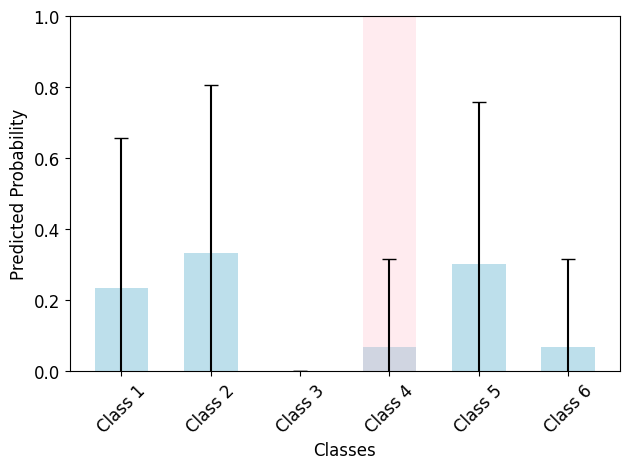

In [197]:
classes = ['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6']
mean_predict_plot = pred_mean[PLOT]
std_predict_plot = pred_sd[PLOT]
truth_plot = true_classes[PLOT]

# Plotting
fig, ax = plt.subplots()


# Bar plot for mean predicted probabilities
bar_width = 0.6
bars = ax.bar(classes, mean_predict_plot, yerr=std_predict_plot, capsize=5, color='lightblue', alpha=0.8, width=bar_width)
ax.bar(classes[truth_plot], 1, color='pink', alpha=0.3, width=bar_width)

# Adding titles and labels
ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Predicted Probability', fontsize=12)
ax.set_ylim(0, 1)  # Ensuring the y-axis ranges from 0 to 1

# Show the plot
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [169]:
print(pred_mean)

[[1.4848704e-02 4.9296521e-02 6.9857967e-01 2.3381965e-01 3.2812983e-03
  1.7417994e-04]
 [1.1922413e-02 4.4949707e-02 4.3016407e-01 4.9726877e-01 1.5129733e-02
  5.6532974e-04]
 [7.5055896e-03 3.1227801e-02 8.1198210e-01 1.4815374e-01 1.1058333e-03
  2.4914845e-05]
 ...
 [2.0474321e-03 1.2669205e-02 1.9398522e-01 7.3932391e-01 4.9923215e-02
  2.0509728e-03]
 [1.3255784e-02 5.3707555e-02 4.6096462e-01 4.5898375e-01 1.2583649e-02
  5.0462486e-04]
 [1.1065985e-03 7.4201054e-03 9.2603648e-01 6.5376095e-02 6.0577389e-05
  1.8542563e-07]]


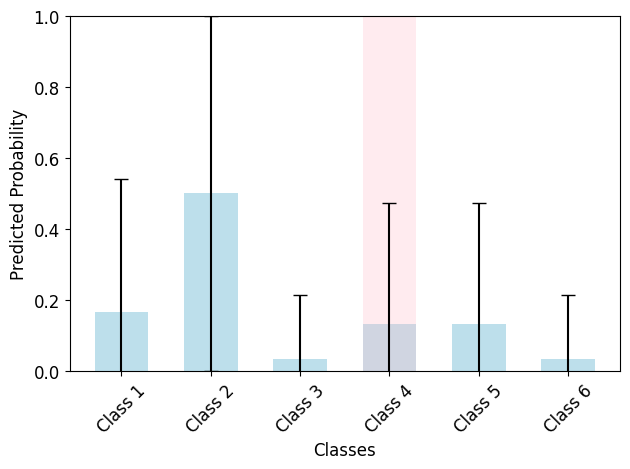

In [198]:
classes = ['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6']
mean_predict_plot = pred_mean[(PLOT+1)]
std_predict_plot = pred_sd[(PLOT+1)]
truth_plot = true_classes[(PLOT+1)]

# Plotting
fig, ax = plt.subplots()


# Bar plot for mean predicted probabilities
bar_width = 0.6
bars = ax.bar(classes, mean_predict_plot, yerr=std_predict_plot, capsize=5, color='lightblue', alpha=0.8, width=bar_width)
ax.bar(classes[truth_plot], 1, color='pink', alpha=0.3, width=bar_width)

# Adding titles and labels
ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Predicted Probability', fontsize=12)
ax.set_ylim(0, 1)  # Ensuring the y-axis ranges from 0 to 1

# Show the plot
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [199]:
pred_mean, pred_std, lime_explanations, shap_explanations = model.predict_with_exp(X_test_scaled.loc[PLOT:PLOT+1], X_train_scaled, num_samples=30)

Inputs shape before expansion in tokenizer call: (100, 11)
Embeddings shape after expansion and weight application in tokenizer call: (100, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (100, 11, 20)
Shape after feature_tokenizer in model call: (100, 11, 20)
Attention mask shape: (100, 11, 11)
Input shape to Transformer: (100, 11, 20)
Shape after Transformer block: (100, 11, 20)
Shape after Transformer block: (100, 11, 20)
Shape after Global pooling: (100, 20)
Shape after MLP layer: (100, 128)
Shape after MLP layer: (100, 64)
Shape after output layer: (100, 1)
Shape after transformer: (100, 1)
Inputs shape before expansion in tokenizer call: (1, 11)
Embeddings shape after expansion and weight application in tokenizer call: (1, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 11, 20)
Shape after feature_tokenizer in model call: (1, 11, 20)
Attention mask shape: (1, 11, 11)
Input shape to Transformer: (1, 11, 20)
Shape after Transformer bl

  0%|          | 0/1 [00:00<?, ?it/s]

Inputs shape before expansion in tokenizer call: (1, 11)
Embeddings shape after expansion and weight application in tokenizer call: (1, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 11, 20)
Shape after feature_tokenizer in model call: (1, 11, 20)
Attention mask shape: (1, 11, 11)
Input shape to Transformer: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after output layer: (1, 1)
Shape after transformer: (1, 1)
Inputs shape before expansion in tokenizer call: (204600, 11)
Embeddings shape after expansion and weight application in tokenizer call: (204600, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (204600, 11, 20)
Shape after feature_tokenizer in model call: (204600, 11, 20)
Attention mask shape: (204600, 11, 11)
Input shape to Transformer: (204600, 11, 20)
Shape after Transforme

  0%|          | 0/1 [00:00<?, ?it/s]

Inputs shape before expansion in tokenizer call: (1, 11)
Embeddings shape after expansion and weight application in tokenizer call: (1, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 11, 20)
Shape after feature_tokenizer in model call: (1, 11, 20)
Attention mask shape: (1, 11, 11)
Input shape to Transformer: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after output layer: (1, 1)
Shape after transformer: (1, 1)
Inputs shape before expansion in tokenizer call: (204600, 11)
Embeddings shape after expansion and weight application in tokenizer call: (204600, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (204600, 11, 20)
Shape after feature_tokenizer in model call: (204600, 11, 20)
Attention mask shape: (204600, 11, 11)
Input shape to Transformer: (204600, 11, 20)
Shape after Transforme

...

Inputs shape before expansion in tokenizer call: (1, 11)
Embeddings shape after expansion and weight application in tokenizer call: (1, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 11, 20)
Shape after feature_tokenizer in model call: (1, 11, 20)
Attention mask shape: (1, 11, 11)
Input shape to Transformer: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after output layer: (1, 1)
Shape after transformer: (1, 1)
Inputs shape before expansion in tokenizer call: (204600, 11)
Embeddings shape after expansion and weight application in tokenizer call: (204600, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (204600, 11, 20)
Shape after feature_tokenizer in model call: (204600, 11, 20)
Attention mask shape: (204600, 11, 11)
Input shape to Transformer: (204600, 11, 20)
Shape after Transforme

  0%|          | 0/1 [00:00<?, ?it/s]

Inputs shape before expansion in tokenizer call: (1, 11)
Embeddings shape after expansion and weight application in tokenizer call: (1, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 11, 20)
Shape after feature_tokenizer in model call: (1, 11, 20)
Attention mask shape: (1, 11, 11)
Input shape to Transformer: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after output layer: (1, 1)
Shape after transformer: (1, 1)
Inputs shape before expansion in tokenizer call: (204600, 11)
Embeddings shape after expansion and weight application in tokenizer call: (204600, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (204600, 11, 20)
Shape after feature_tokenizer in model call: (204600, 11, 20)
Attention mask shape: (204600, 11, 11)
Input shape to Transformer: (204600, 11, 20)
Shape after Transforme

  0%|          | 0/1 [00:00<?, ?it/s]

Inputs shape before expansion in tokenizer call: (1, 11)
Embeddings shape after expansion and weight application in tokenizer call: (1, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 11, 20)
Shape after feature_tokenizer in model call: (1, 11, 20)
Attention mask shape: (1, 11, 11)
Input shape to Transformer: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Transformer block: (1, 11, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after output layer: (1, 1)
Shape after transformer: (1, 1)
Inputs shape before expansion in tokenizer call: (204600, 11)
Embeddings shape after expansion and weight application in tokenizer call: (204600, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (204600, 11, 20)
Shape after feature_tokenizer in model call: (204600, 11, 20)
Attention mask shape: (204600, 11, 11)
Input shape to Transformer: (204600, 11, 20)
Shape after Transforme

In [200]:
for i, explanation in enumerate(lime_explanations):
    print(f"Explanation {i + 1}:")
    print("As List of Tuples (feature_id, weight):")
    for feature_id, weight in explanation[0].as_list():
        print(f"Feature {feature_id}: {weight}")

    print("\n")

Explanation 1:
As List of Tuples (feature_id, weight):
Feature -0.17 < chlorides <= 0.05: 0.031138132431544452
Feature sulphates <= -0.64: -0.020114364731942107
Feature -0.83 < free sulfur dioxide <= -0.24: -0.01995166169077971
Feature -0.70 < fixed acidity <= -0.24: -0.01888191072925279
Feature -0.87 < alcohol <= -0.23: 0.014281750119175814
Feature volatile acidity > 0.61: 0.011716495339737277
Feature -0.46 < residual sugar <= -0.24: 0.0055194803714526544
Feature -0.61 < density <= -0.04: -0.00444246503933059
Feature citric acid <= -0.92: 0.001952961473219446
Feature -0.75 < total sulfur dioxide <= -0.27: 0.001274946830311633
Feature -0.69 < pH <= 0.01: 0.000580055116663525


Explanation 2:
As List of Tuples (feature_id, weight):
Feature -0.27 < total sulfur dioxide <= 0.46: -0.027787081086929327
Feature -0.64 < sulphates <= -0.23: -0.021052722202357786
Feature -0.24 < free sulfur dioxide <= 0.54: 0.02092015500391265
Feature 0.01 < pH <= 0.58: -0.02085459932716405
Feature citric acid 

In [201]:
print(len(shap_explanations[0]))
values_try = shap_explanations[0]
print()

30


In [211]:
def extract_feature_number(feature_name):
        match = re.search(r'feature_(\d+)', feature_name)
        return int(match.group(1)) if match else float('inf')
def sort_features_by_name(explanation):
    # Extract the features and their weights
    features_weights = explanation.as_list()
    # Sort the features based on their names
    sorted_features_weights = sorted(features_weights, key=lambda x: extract_feature_number(x[0]))
    return sorted_features_weights


feature_weights = defaultdict(list)

for explanation in lime_explanations[1]:
    sorted_features = sort_features_by_name(explanation)
    for feature, weight in sorted_features:
        feature_weights[feature].append(weight)

feature_stats = {}
for feature, weights in feature_weights.items():
    mean_weight = np.mean(weights)
    std_weight = np.std(weights)
    feature_stats[feature] = {'mean': mean_weight, 'std': std_weight}

print(feature_stats)

{'-0.27 < total sulfur dioxide <= 0.46': {'mean': -0.0027176757406386347, 'std': 0.014001851578984518}, '-0.64 < sulphates <= -0.23': {'mean': -0.0035709932262773156, 'std': 0.01757118630208415}, '-0.24 < free sulfur dioxide <= 0.54': {'mean': -0.0037244269394205304, 'std': 0.016156078849247524}, '0.01 < pH <= 0.58': {'mean': -0.0011017409509118286, 'std': 0.014207600049176494}, 'citric acid <= -0.92': {'mean': -0.0006316942300464032, 'std': 0.021353059031226716}, '-0.04 < density <= 0.58': {'mean': -0.0024894998634813407, 'std': 0.016525587143581457}, '-0.70 < fixed acidity <= -0.24': {'mean': 0.006875714627500457, 'std': 0.016278000545833074}, '-0.05 < volatile acidity <= 0.61': {'mean': 0.0013898518660149283, 'std': 0.015279540609696093}, '-0.35 < chlorides <= -0.17': {'mean': -0.0002357303524899595, 'std': 0.016781755272296073}, '-0.46 < residual sugar <= -0.24': {'mean': 0.0032098797546415057, 'std': 0.016126759124433256}, '-0.87 < alcohol <= -0.23': {'mean': -0.002077245406113625

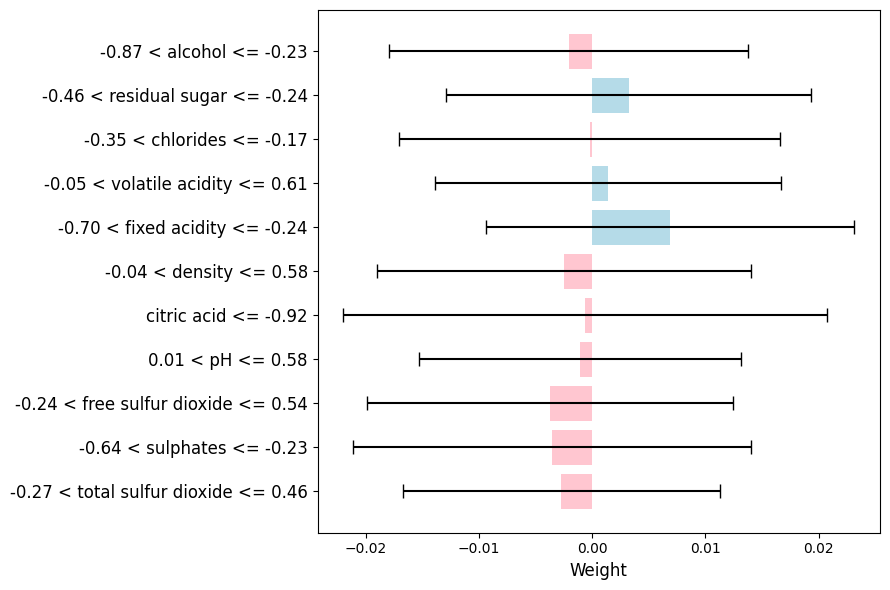

weights [-0.0027176757406386347, -0.0035709932262773156, -0.0037244269394205304, -0.0011017409509118286, -0.0006316942300464032, -0.0024894998634813407, 0.006875714627500457, 0.0013898518660149283, -0.0002357303524899595, 0.0032098797546415057, -0.0020772454061136255] sd [0.014001851578984518, 0.01757118630208415, 0.016156078849247524, 0.014207600049176494, 0.021353059031226716, 0.016525587143581457, 0.016278000545833074, 0.015279540609696093, 0.016781755272296073, 0.016126759124433256, 0.015833452685287804]


In [212]:
features = list(feature_stats.keys())
mean_weights = [feature_stats[feature]['mean'] for feature in features]
std_weights = [feature_stats[feature]['std'] for feature in features]

colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights]

feature_ids = range(len(mean_weights))
plt.figure(figsize=(9, 6))
plt.barh(feature_ids, mean_weights, xerr=std_weights, capsize=5, alpha=0.9, color=colors)
plt.yticks(feature_ids, features, fontsize=12)
plt.xlabel("Weight", fontsize=12)
plt.tight_layout()
plt.show()

print("weights", mean_weights, "sd", std_weights)

In [213]:
shap_features = X_test.loc[[PLOT]].columns.tolist()

In [214]:
# Check the length of gbt_explanation_shap
print("Number of SHAP explanation objects:", len(shap_explanations[1]))

# Attempt to stack SHAP values
stacked_shap_values = np.vstack([shap_explanations[1][i] for i in range(len(shap_explanations[1]))])

# Print the stacked SHAP values
print("Shape of stacked SHAP values:", stacked_shap_values.shape)
print("Stacked SHAP values:\n", stacked_shap_values)

Number of SHAP explanation objects: 30
Shape of stacked SHAP values: (30, 11, 6)
Stacked SHAP values:
 [[[-2.73194132e-02  3.92184183e-02 -1.10962409e-03 -1.01253265e-02
    4.64766340e-04 -1.12882081e-03]
  [-1.49682953e-02  4.87646836e-02 -2.53717096e-04 -1.32263884e-02
   -1.54020913e-02 -4.91419142e-03]
  [-1.33081696e-02  4.50755902e-02 -2.33758213e-04 -6.22232416e-03
   -2.42415936e-02 -1.06974464e-03]
  ...
  [-1.92433495e-02  4.36961830e-02 -2.17945023e-03 -6.07270086e-03
   -1.70888351e-02  8.88152682e-04]
  [-1.35006264e-02  3.55359241e-02 -1.83599032e-04 -6.09784047e-03
   -5.30693118e-03 -1.04469271e-02]
  [-1.23538892e-02  4.80437984e-02 -1.18888899e-03 -1.77833460e-03
   -3.25917647e-02 -1.30920966e-04]]

 [[-1.76397853e-02 -4.72049084e-02  2.76058914e-03 -9.86919360e-03
    7.18499713e-02  1.03326879e-04]
  [-6.35395059e-03 -5.50755185e-02 -7.95204203e-04 -1.83626549e-03
    6.91621267e-02 -5.10118790e-03]
  [-9.55309804e-03 -5.28851207e-02  3.92789133e-04 -1.22114585e-0

In [215]:
mean_shap_values = np.mean(stacked_shap_values, axis=0)

# Calculate standard deviation of SHAP values across the 80 explanations
sd_shap_values = np.std(stacked_shap_values, axis=0)

# Now you have mean_shap_values and sd_shap_values
print("Mean SHAP values shape:", mean_shap_values.shape)
print("Standard deviation of SHAP values shape:", sd_shap_values.shape)
print(mean_shap_values)

Mean SHAP values shape: (11, 6)
Standard deviation of SHAP values shape: (11, 6)
[[ 4.15737959e-03 -1.19544848e-02 -7.86820762e-04  1.63852892e-03
   1.03986248e-02 -3.45322773e-03]
 [ 3.38124647e-03 -1.19692806e-02  3.20154944e-05  1.98516858e-03
   1.00883292e-02 -3.51747907e-03]
 [ 1.50350703e-03 -7.98637566e-03  1.74780296e-04  1.04006810e-03
   9.36675031e-03 -4.09873008e-03]
 [ 5.50667876e-03 -1.12424508e-02 -3.34013124e-04  4.44159689e-04
   8.99293300e-03 -3.36730748e-03]
 [ 8.50490451e-03 -1.43631652e-02 -8.07607935e-04  2.32394109e-04
   1.00448222e-02 -3.61134767e-03]
 [ 3.07693071e-03 -1.06428385e-02 -5.57239789e-04  1.71432426e-03
   9.27960933e-03 -2.87078602e-03]
 [ 6.22758045e-03 -1.17474717e-02  1.06758508e-04  1.64528796e-03
   6.74532279e-03 -2.97747803e-03]
 [ 2.89530339e-03 -1.07726444e-02  5.75847097e-05  7.22610199e-04
   1.09978841e-02 -3.90073798e-03]
 [ 3.95947316e-03 -1.19479062e-02 -3.50087615e-04  2.16549674e-03
   9.98144039e-03 -3.80841646e-03]
 [ 2.32858

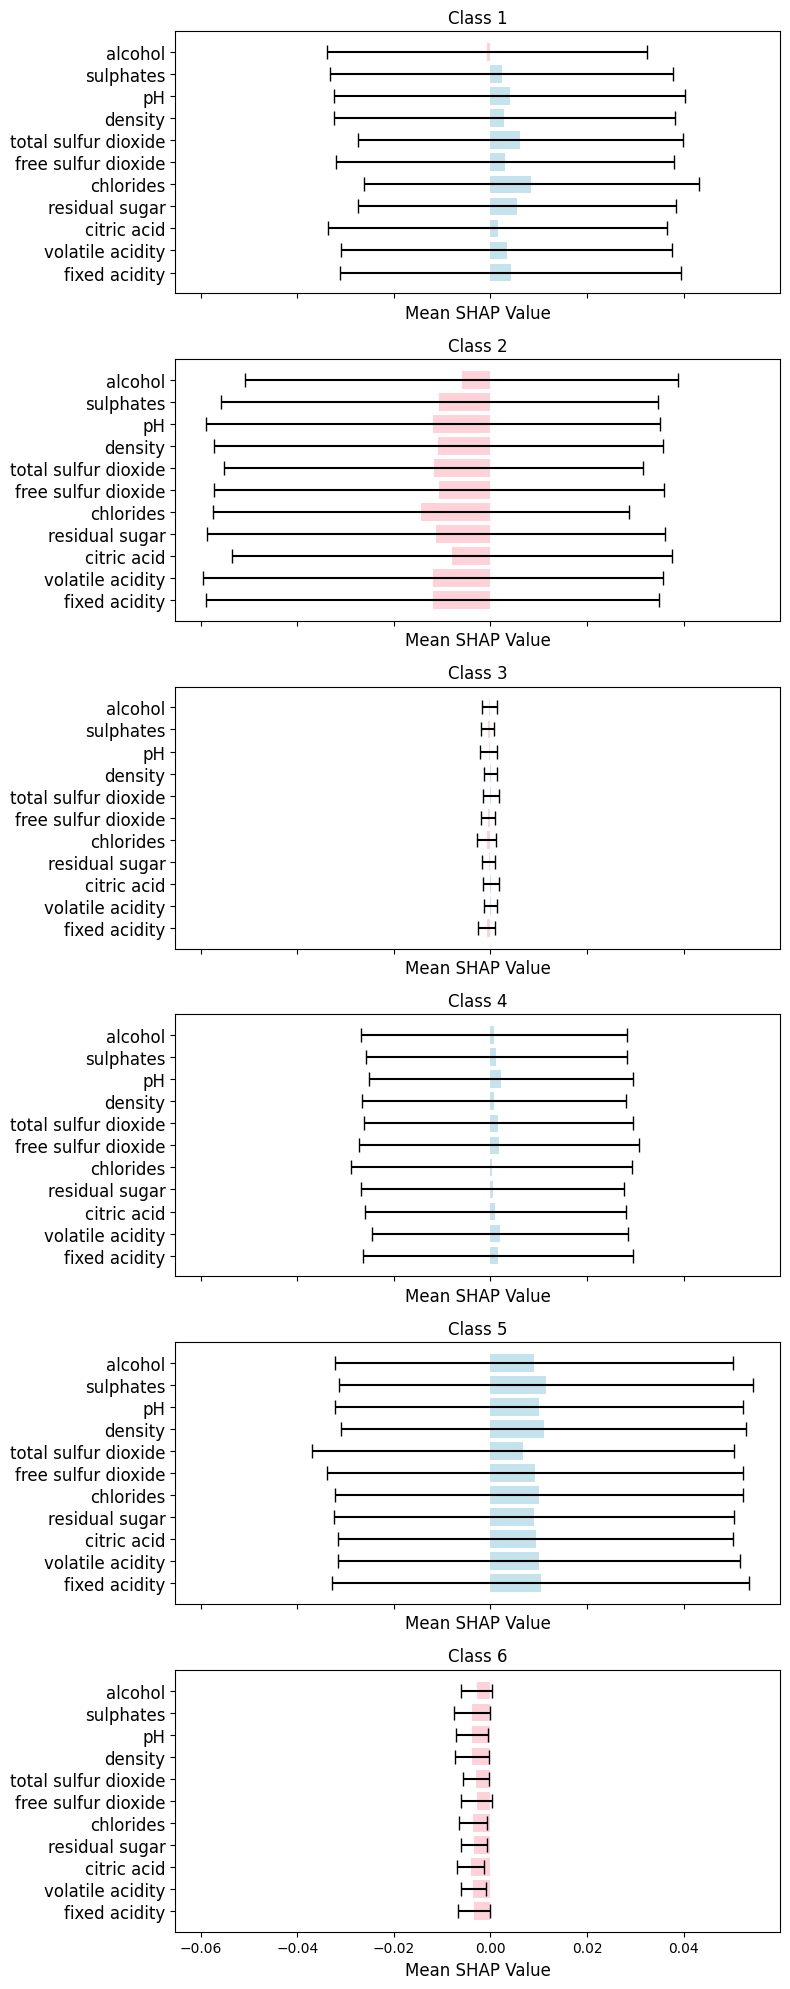

In [216]:
num_features, num_classes = mean_shap_values.shape
colors = np.where(mean_shap_values >= 0, 'lightblue', 'pink')

feature_ids = range(len(mean_shap_values))
# Plotting each class separately
fig, axs = plt.subplots(num_classes, figsize=(8, 20), sharex=True)

for cls in range(num_classes):
    ax = axs[cls]
    ax.barh(np.arange(num_features), mean_shap_values[:, cls], xerr=sd_shap_values[:, cls], align='center', alpha=0.7, capsize=5, color=colors[:, cls])
    ax.set_yticks(feature_ids, shap_features, fontsize=12)
    ax.set_title(f'Class {cls+1}')
    ax.set_xlabel('Mean SHAP Value', fontsize=12)
    ax.grid(False)

plt.tight_layout()
plt.show()

In [217]:
# Compute absolute sum across classes (axis=2)
absolute_sum_shap_values = np.abs(stacked_shap_values).sum(axis=2)
sum_shap_values = stacked_shap_values.sum(axis=2)
# Print the shape of the absolute sum SHAP values
print("Shape of absolute sum SHAP values:", absolute_sum_shap_values.shape)

mean_shap_sum = np.mean(absolute_sum_shap_values, axis=0)

# Calculate standard deviation of SHAP values across the 80 explanations
sd_shap_sum = np.std(absolute_sum_shap_values, axis=0)

# Now you have mean_shap_values and sd_shap_values
print("Mean SHAP values shape:", mean_shap_sum.shape)
print("Standard deviation of SHAP values shape:", sd_shap_sum.shape)

Shape of absolute sum SHAP values: (30, 11)
Mean SHAP values shape: (11,)
Standard deviation of SHAP values shape: (11,)


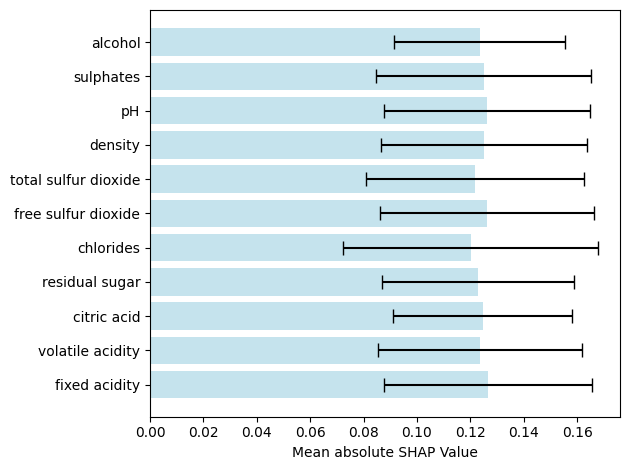

In [218]:
# Plotting
fig, ax = plt.subplots()

# Plot bars for mean SHAP values
bars = ax.barh(shap_features, mean_shap_sum, xerr=sd_shap_sum, align='center', color='lightblue',alpha=0.7, capsize=5)

# Adding labels and title
ax.set_xlabel('Mean absolute SHAP Value')

# Show plot
plt.tight_layout()
plt.show()

Initial performance - Loss: 1.1195, Accuracy: 0.5983
Performance after randomization - Loss: 20182.6699, Accuracy: 0.0044
Sanity check passed: Model performance dropped significantly after weight randomization.
Inputs shape before expansion in tokenizer call: (32, 11)
Embeddings shape after expansion and weight application in tokenizer call: (32, 11, 20)
Embeddings shape after layer normalization in tokenizer call: (32, 11, 20)
Shape after feature_tokenizer in model call: (32, 11, 20)
Attention mask shape: (32, 11, 11)
Input shape to Transformer: (32, 11, 20)
Shape after Transformer block: (32, 11, 20)
Shape after Transformer block: (32, 11, 20)
Shape after Global pooling: (32, 20)
Shape after MLP layer: (32, 128)
Shape after MLP layer: (32, 64)
Shape after output layer: (32, 1)
Shape after transformer: (32, 1)
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/stepInputs shape before expansion in tokenizer call: (None, 11)
Embeddings shape after expansion and weight application in tokenizer call: (Non

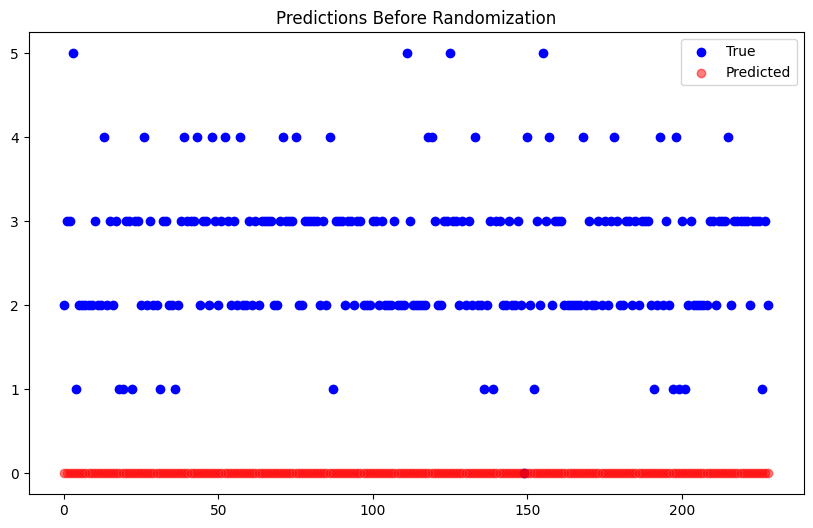

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


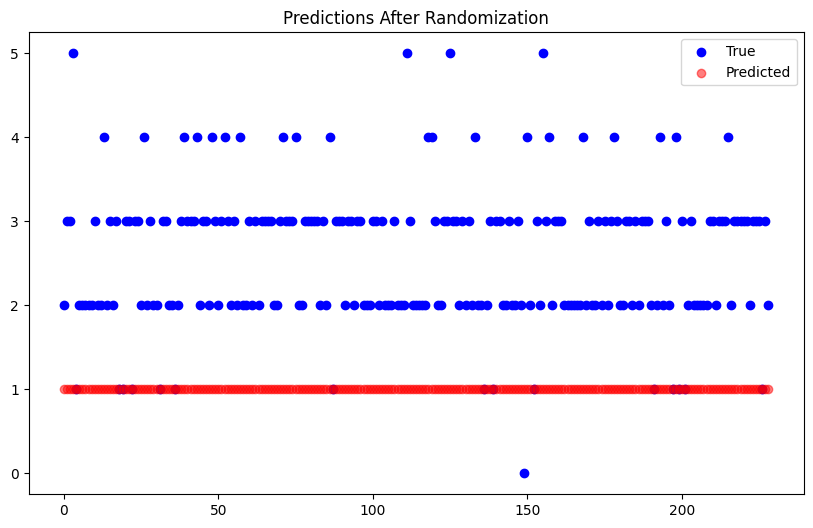

In [192]:
def randomize_weights(model):
    weights = model.get_weights()
    new_weights = []
    for w in weights:
        new_w = np.random.normal(size=w.shape)
        new_weights.append(new_w)
    model.set_weights(new_weights)
    
def sanity_check(model, X_test, y_test):
    # Get the initial performance
    initial_loss, initial_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Initial performance - Loss: {initial_loss:.4f}, Accuracy: {initial_accuracy:.4f}")
    
    # Randomize weights
    randomize_weights(model)
    
    # Get performance after randomization
    random_loss, random_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Performance after randomization - Loss: {random_loss:.4f}, Accuracy: {random_accuracy:.4f}")
    
    # Check if accuracy dropped significantly
    if random_accuracy < initial_accuracy * 0.5:  # You can adjust this threshold
        print("Sanity check passed: Model performance dropped significantly after weight randomization.")
    else:
        print("Sanity check failed: Model performance did not drop as expected after weight randomization.")
        
sanity_check(model, X_test_scaled, y_test)

import matplotlib.pyplot as plt

def plot_predictions(model, X_test, y_test, title):
    predictions = model.predict(X_test)
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(y_test)), np.argmax(y_test, axis=1), c='blue', label='True')
    plt.scatter(range(len(predictions)), np.argmax(predictions, axis=1), c='red', alpha=0.5, label='Predicted')
    plt.title(title)
    plt.legend()
    plt.show()

# Before randomization
plot_predictions(model, X_test_scaled, y_test, "Predictions Before Randomization")

# Randomize weights
randomize_weights(model)

# After randomization
plot_predictions(model, X_test_scaled, y_test, "Predictions After Randomization")